# Task-1

In [42]:
#import a library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)

In [43]:
#range between 1-7 and if number is >4 ten print it and also find a prime number
sample_space = np.arange(1, 7)

greater_than_4 = sample_space[sample_space > 4]
prime_numbers = sample_space[np.isin(sample_space, [2, 3, 5])]

print("Sample space:", sample_space)
print("Greater than 4:", greater_than_4)
print("Prime numbers:", prime_numbers)

Sample space: [1 2 3 4 5 6]
Greater than 4: [5 6]
Prime numbers: [2 3 5]


In [44]:
#calculate a probability
P_greater_4 = len(greater_than_4) / len(sample_space)
P_prime = len(prime_numbers) / len(sample_space)

print("P(number > 4):", P_greater_4)
print("P(prime):", P_prime)

P(number > 4): 0.3333333333333333
P(prime): 0.5


In [45]:
rolls = rng.integers(1, 7, size=10_000)

greater_4_sim = rolls > 4
prime_sim = np.isin(rolls, [2, 3, 5])

print("P(number > 4) simulated:", greater_4_sim.mean())
print("P(prime) simulated:", prime_sim.mean())

P(number > 4) simulated: 0.3343
P(prime) simulated: 0.4933


In [46]:
running_fraction = np.cumsum(prime_sim) / np.arange(1, len(rolls) + 1)

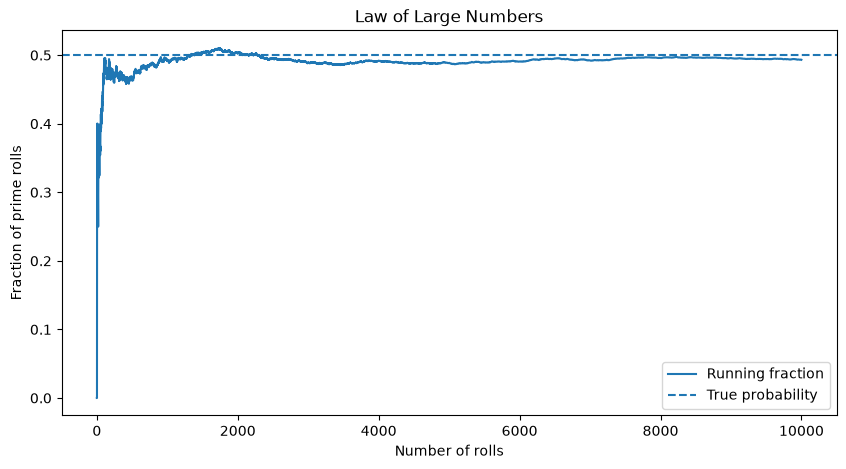

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(running_fraction, label="Running fraction")
plt.axhline(P_prime, linestyle="--", label="True probability")

plt.xlabel("Number of rolls")
plt.ylabel("Fraction of prime rolls")
plt.title("Law of Large Numbers")
plt.legend()
plt.show()

# Task-2

In [48]:
# Roll two dice (all 36 outcomes). Compute P(sum = 8), and P(sum = 8 given the first die is a 3).
from itertools import product

outcomes = list(product(range(1, 7), repeat=2))

print("Number of outcomes:", len(outcomes))
print(outcomes[:10])

Number of outcomes: 36
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4)]


In [49]:
#Compute P(sum = 8), and P(sum = 8 given the first die is a 3).
sum_8 = [outcome for outcome in outcomes if sum(outcome) == 8]

first_die_3 = [outcome for outcome in outcomes if outcome[0] == 3]

sum_8_and_first_3 = [
    outcome for outcome in outcomes
    if sum(outcome) == 8 and outcome[0] == 3
]

print("Sum = 8:", sum_8)
print("First die = 3:", first_die_3)
print("Both:", sum_8_and_first_3)

Sum = 8: [(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)]
First die = 3: [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]
Both: [(3, 5)]


In [50]:
P_sum_8 = len(sum_8) / len(outcomes)

print("P(sum = 8):", P_sum_8)

P(sum = 8): 0.1388888888888889


In [51]:
P_first_3 = len(first_die_3) / len(outcomes)
P_both = len(sum_8_and_first_3) / len(outcomes)

P_sum_8_given_first_3 = P_both / P_first_3

print("P(sum = 8 | first die = 3):", P_sum_8_given_first_3)

P(sum = 8 | first die = 3): 0.16666666666666666


In [52]:
restricted_world = first_die_3

successful = [
    outcome for outcome in restricted_world
    if sum(outcome) == 8
]

direct_conditional = len(successful) / len(restricted_world)

print("Conditional probability by counting:", direct_conditional)

Conditional probability by counting: 0.16666666666666666


In [53]:
product_probability = P_sum_8 * P_first_3

print("P(A and B):", P_both)
print("P(A) x P(B):", product_probability)

P(A and B): 0.027777777777777776
P(A) x P(B): 0.023148148148148147


In [54]:
# Find all outcomes where the first value is even
A = [o for o in outcomes if o[0] % 2 == 0]

# Find all outcomes where the second value is even
B = [o for o in outcomes if o[1] % 2 == 0]

# Find outcomes where both the first and second values are even
A_and_B = [
    o for o in outcomes
    if o[0] % 2 == 0 and o[1] % 2 == 0
]

# Calculate the probability of event A
P_A = len(A) / 36

# Calculate the probability of event B
P_B = len(B) / 36

# Calculate the probability of both A and B happening
P_A_and_B = len(A_and_B) / 36

# Print the probability of A
print("P(A):", P_A)

# Print the probability of B
print("P(B):", P_B)

# Print the probability of A and B together
print("P(A and B):", P_A_and_B)

# For independent events, P(A and B) should equal P(A) × P(B)
print("P(A) x P(B):", P_A * P_B)

P(A): 0.5
P(B): 0.5
P(A and B): 0.25
P(A) x P(B): 0.25


In [55]:
# Generate 100,000 random dice rolls for the first die (values 1 to 6)
d1 = rng.integers(1, 7, size=100_000)

# Generate 100,000 random dice rolls for the second die
d2 = rng.integers(1, 7, size=100_000)

# Select only the trials where the first die rolled 3
condition = d1 == 3

# Get the second die results only for trials where d1 was 3
simulated_d2 = d2[condition]

# Check how many of those trials have a sum of 8
# Since d1 is already 3, d2 must be 5 to make the sum 8
simulated_sum_8 = (d1[condition] + d2[condition]) == 8

# Calculate the proportion of successful trials
# mean() gives the simulated probability
print("Simulated conditional probability:",
      simulated_sum_8.mean())

Simulated conditional probability: 0.17077391252461363


# Task-3

In [56]:
# Probability that a randomly selected person has the disease
P_disease = 0.02

# Probability of getting a positive test result when the person has the disease
P_pos_given_disease = 0.98

# Probability of getting a positive test result when the person is healthy
P_pos_given_healthy = 0.10

# Probability that a person is healthy
P_healthy = 1 - P_disease

# Calculate the overall probability of getting a positive test result
# This includes positive results from both diseased and healthy people
P_positive = (
    P_pos_given_disease * P_disease
    + P_pos_given_healthy * P_healthy
)

# Calculate the probability that a person actually has the disease
# given that their test result is positive (Bayes' theorem)
P_disease_given_pos = (
    P_pos_given_disease * P_disease
    / P_positive
)

# Print the prior probability of having the disease
print("Prior P(disease):", P_disease)

# Print the probability of a positive test when disease is present
print("P(positive | disease):", P_pos_given_disease)

# Print the probability of a positive test when the person is healthy
print("P(positive | healthy):", P_pos_given_healthy)

# Print the overall probability of getting a positive test
print("P(positive):", P_positive)

# Print the probability of actually having the disease given a positive test
print("P(disease | positive):", P_disease_given_pos)

Prior P(disease): 0.02
P(positive | disease): 0.98
P(positive | healthy): 0.1
P(positive): 0.11760000000000001
P(disease | positive): 0.16666666666666666


In [57]:
# Number of people to simulate
n = 1_000_000

# Randomly decide which people have the disease
# Each person has a 2% chance of having the disease
disease = rng.random(n) < P_disease

# Create an array to store whether each person's test is positive
test_positive = np.zeros(n, dtype=bool)

# Select only the people who have the disease
sick = disease

# Simulate test results for sick people
# 98% of sick people are expected to get a positive result
test_positive[sick] = rng.random(sick.sum()) < P_pos_given_disease

# Select only the people who are healthy
# ~ means NOT, so ~disease means healthy
healthy = ~disease

# Simulate test results for healthy people
# 10% of healthy people are expected to get a positive result
test_positive[healthy] = rng.random(healthy.sum()) < P_pos_given_healthy

# Among people who tested positive, calculate the proportion
# who actually have the disease
posterior_sim = disease[test_positive].mean()

# Print the simulated probability of having the disease
# given that the test result is positive
print("Simulated P(disease | positive):", posterior_sim)


Simulated P(disease | positive): 0.16729296079483968


In [58]:
# Try different disease prevalence values:
# 0.1%, 2%, and 20%
prevalences = [0.001, 0.02, 0.20]

# Create an empty list to store the calculated probabilities
results = []

# Repeat the calculation for each prevalence value
for prevalence in prevalences:

    # Calculate the probability of being healthy
    healthy = 1 - prevalence

    # Calculate the overall probability of getting a positive test
    # Positive results can come from sick people or healthy people
    positive = (
        P_pos_given_disease * prevalence
        + P_pos_given_healthy * healthy
    )

    # Use Bayes' theorem to calculate:
    # P(disease | positive)
    posterior = (
        P_pos_given_disease * prevalence
        / positive
    )

    # Store the result
    results.append(posterior)

# Go through each prevalence and its corresponding result
for prevalence, posterior in zip(prevalences, results):

    # Print prevalence and probability of disease given a positive test
    # .1% formats prevalence as a percentage with 1 decimal place
    # .2% formats posterior as a percentage with 2 decimal places
    print(
        f"Prevalence: {prevalence:.1%}, "
        f"P(disease | positive): {posterior:.2%}"
    )

Prevalence: 0.1%, P(disease | positive): 0.97%
Prevalence: 2.0%, P(disease | positive): 16.67%
Prevalence: 20.0%, P(disease | positive): 71.01%


# Task-4

In [59]:
P_spam = 0.40
P_free_given_spam = 0.30
P_free_given_ham = 0.02

P_ham = 1 - P_spam

P_free = (
    P_free_given_spam * P_spam
    + P_free_given_ham * P_ham
)

P_spam_given_free = (
    P_free_given_spam * P_spam
    / P_free
)

print("Prior P(spam):", P_spam)
print("P(free | spam):", P_free_given_spam)
print("P(free | ham):", P_free_given_ham)
print("P(free):", P_free)
print("P(spam | free):", P_spam_given_free)

Prior P(spam): 0.4
P(free | spam): 0.3
P(free | ham): 0.02
P(free): 0.132
P(spam | free): 0.9090909090909091


In [60]:
n = 1_000_000

spam = rng.random(n) < P_spam

contains_free = np.zeros(n, dtype=bool)

spam_mask = spam
contains_free[spam_mask] = (
    rng.random(spam_mask.sum()) < P_free_given_spam
)

ham_mask = ~spam
contains_free[ham_mask] = (
    rng.random(ham_mask.sum()) < P_free_given_ham
)

posterior_sim = spam[contains_free].mean()

print("Simulated P(spam | free):", posterior_sim)

Simulated P(spam | free): 0.910391936105423


# Task-5

In [61]:
values = np.arange(1, 7)

probs = np.ones(6) / 6

E_X = np.sum(values * probs)

Var_X = np.sum(values**2 * probs) - E_X**2

print("Expected value:", E_X)
print("Variance:", Var_X)

Expected value: 3.5
Variance: 2.916666666666666


In [62]:
rolls = rng.integers(1, 7, size=100_000)

sim_mean = rolls.mean()
sim_variance = rolls.var()

print("Simulated mean:", sim_mean)
print("Simulated variance:", sim_variance)

Simulated mean: 3.49944
Simulated variance: 2.9046996864


In [63]:
values = np.arange(1, 7)

weights = np.array([1, 1, 1, 1, 1, 2])

weighted_probs = weights / weights.sum()

weighted_mean = np.sum(values * weighted_probs)

weighted_variance = (
    np.sum(values**2 * weighted_probs)
    - weighted_mean**2
)

print("Weighted probabilities:", weighted_probs)
print("Weighted expected value:", weighted_mean)
print("Weighted variance:", weighted_variance)

Weighted probabilities: [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.28571429]
Weighted expected value: 3.8571428571428568
Weighted variance: 3.2653061224489814


In [64]:
weighted_rolls = rng.choice(
    values,
    size=100_000,
    p=weighted_probs
)

print("Simulated weighted mean:", weighted_rolls.mean())
print("Simulated weighted variance:", weighted_rolls.var())

Simulated weighted mean: 3.86104
Simulated weighted variance: 3.2643501183999994


In [65]:
x = np.arange(0, 11)

binomial_probs = stats.binom.pmf(
    x,
    n=10,
    p=0.5
)

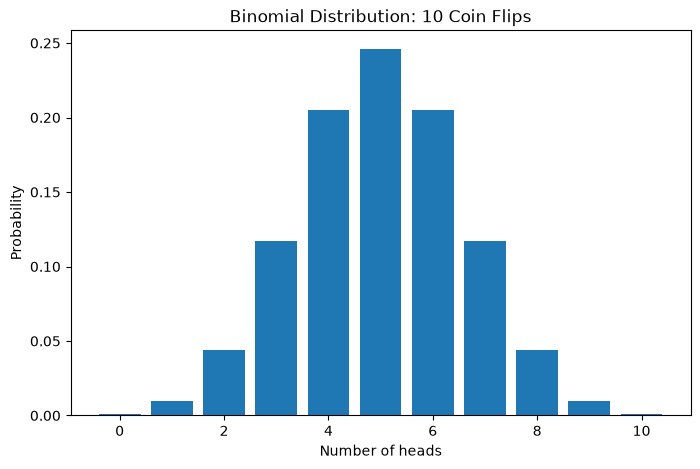

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(x, binomial_probs)

plt.xlabel("Number of heads")
plt.ylabel("Probability")
plt.title("Binomial Distribution: 10 Coin Flips")

plt.show()

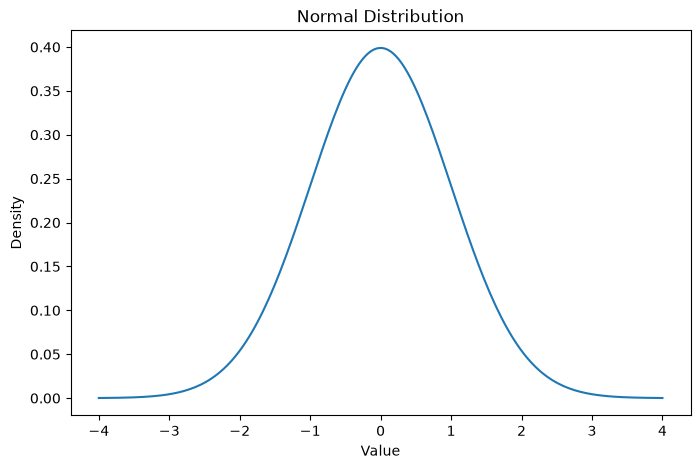

In [67]:
x = np.linspace(-4, 4, 200)

normal_probs = stats.norm.pdf(x)

plt.figure(figsize=(8, 5))

plt.plot(x, normal_probs)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Normal Distribution")

plt.show()

In [68]:
prob_within_1sd = stats.norm.cdf(1) - stats.norm.cdf(-1)

print("Probability within 1 standard deviation:",
      prob_within_1sd)

Probability within 1 standard deviation: 0.6826894921370859


In [69]:
normal_samples = rng.normal(
    loc=0,
    scale=1,
    size=1_000_000
)

within_1sd = np.abs(normal_samples) <= 1

simulated_probability = within_1sd.mean()

print(
    "Simulated probability within 1 SD:",
    simulated_probability
)

Simulated probability within 1 SD: 0.682596
